# Road Network Overview

This notebook loads the Serbian road network, visualises it by road category, and saves styled layers for ArcGIS Pro. This creates the **base map** that all hazard notebooks build upon.

**Key steps:**
1. Load and explore the road network shapefile
2. Visualise by road category (IA, IM, IB, IIA, IIB)
3. Compute road length statistics
4. Save as styled ArcGIS layers

## Step 1: Setup and Imports

In [2]:
import os
import warnings
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.simplefilter(action="ignore", category=FutureWarning)

### Helper functions

In [3]:
# Helper functions

def save_lyrx_layer(gdf, gpkg_path, lyrx_path, layer_name, labels, colors, width_mapping, field, title=None):
    """Save GeoDataFrame to GeoPackage + ArcGIS Pro .lyrx with unique-value symbology."""
    import json as _json

    gdf.to_file(gpkg_path, driver="GPKG", layer=layer_name)
    print(f"Saved GeoPackage → {gpkg_path}")

    try:
        import arcpy
    except ImportError:
        print("arcpy not available — .lyrx skipped. GeoPackage was saved successfully.")
        return

    title = title or layer_name
    gpkg_layer_path = str(gpkg_path.absolute()) + f"/{layer_name}"
    tmp_layer_name = f"tmp_lyr_{layer_name}"
    arcpy.management.MakeFeatureLayer(gpkg_layer_path, tmp_layer_name)
    tmp_lyrx = lyrx_path.with_suffix(".tmp.lyrx")
    arcpy.management.SaveToLayerFile(tmp_layer_name, str(tmp_lyrx), "ABSOLUTE")
    arcpy.management.Delete(tmp_layer_name)

    with open(tmp_lyrx) as f:
        lyrx = _json.load(f)

    def _make_symbol(hex_color, width):
        h = hex_color.lstrip("#")
        r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
        return {
            "type": "CIMSymbolReference",
            "symbol": {
                "type": "CIMLineSymbol",
                "symbolLayers": [{
                    "type": "CIMSolidStroke", "enable": True,
                    "capStyle": "Round", "joinStyle": "Round",
                    "width": width,
                    "color": {"type": "CIMRGBColor", "values": [r, g, b, 100]},
                }],
            },
        }

    renderer = {
        "type": "CIMUniqueValueRenderer",
        "defaultLabel": "<all other values>",
        "defaultSymbolPatch": "Default",
        "defaultSymbol": _make_symbol("#cccccc", 0.5),
        "defaultSymbolVisible": False,
        "fields": [field],
        "groups": [{
            "type": "CIMUniqueValueGroup",
            "classes": [
                {
                    "type": "CIMUniqueValueClass",
                    "label": label, "patch": "Default",
                    "symbol": _make_symbol(color, width_mapping.get(label, 1.0)),
                    "values": [{"type": "CIMUniqueValue", "fieldValues": [label]}],
                    "visible": True,
                }
                for label, color in zip(labels, colors)
            ],
            "heading": field,
        }],
        "useDefaultSymbol": False,
    }

    lyrx["layerDefinitions"][0]["renderer"] = renderer
    lyrx["layerDefinitions"][0]["name"] = title

    with open(lyrx_path, "w") as f:
        _json.dump(lyrx, f, indent=2)

    tmp_lyrx.unlink()
    print(f"Saved layer file → {lyrx_path}")

### Define file paths

In [4]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

for d in [figure_path, arcgis_results, arcgis_gpkg]:
    d.mkdir(parents=True, exist_ok=True)

## Step 2: Load and Explore the Road Network

In [5]:
# Load road network
roads = gpd.read_file(data_path / "DeoniceRSDP-Jul2025..shp")

# Clip to Serbia only (remove Kosovo roads)
world = gpd.read_file(data_path / "ne_10m_admin_0_countries.shp")
country_plot = world.loc[world.SOV_A3 == 'SRB']
roads = gpd.clip(roads, country_plot.to_crs(roads.crs))

print(f"Road segments (Serbia only): {len(roads):,}")
print(f"CRS: {roads.crs}")
print(f"\nColumns: {list(roads.columns)}")
print(f"\nRoad categories:")
print(roads['kategorija'].value_counts())

Road segments (Serbia only): 1,828
CRS: EPSG:4326

Columns: ['objectid', 'oznaka_deo', 'smer', 'kategorija', 'oznaka_put', 'oznaka_poc', 'naziv_poce', 'oznaka_zav', 'naziv_zavr', 'duzina_deo', 'pocetna_st', 'zavrsna_st', 'komentar', 'stanje', 'st_length(', 'geometry']

Road categories:
kategorija
IIA    715
IB     545
IIB    272
IA     220
IM      76
Name: count, dtype: int64


## Step 3: Visualise the Road Network by Category

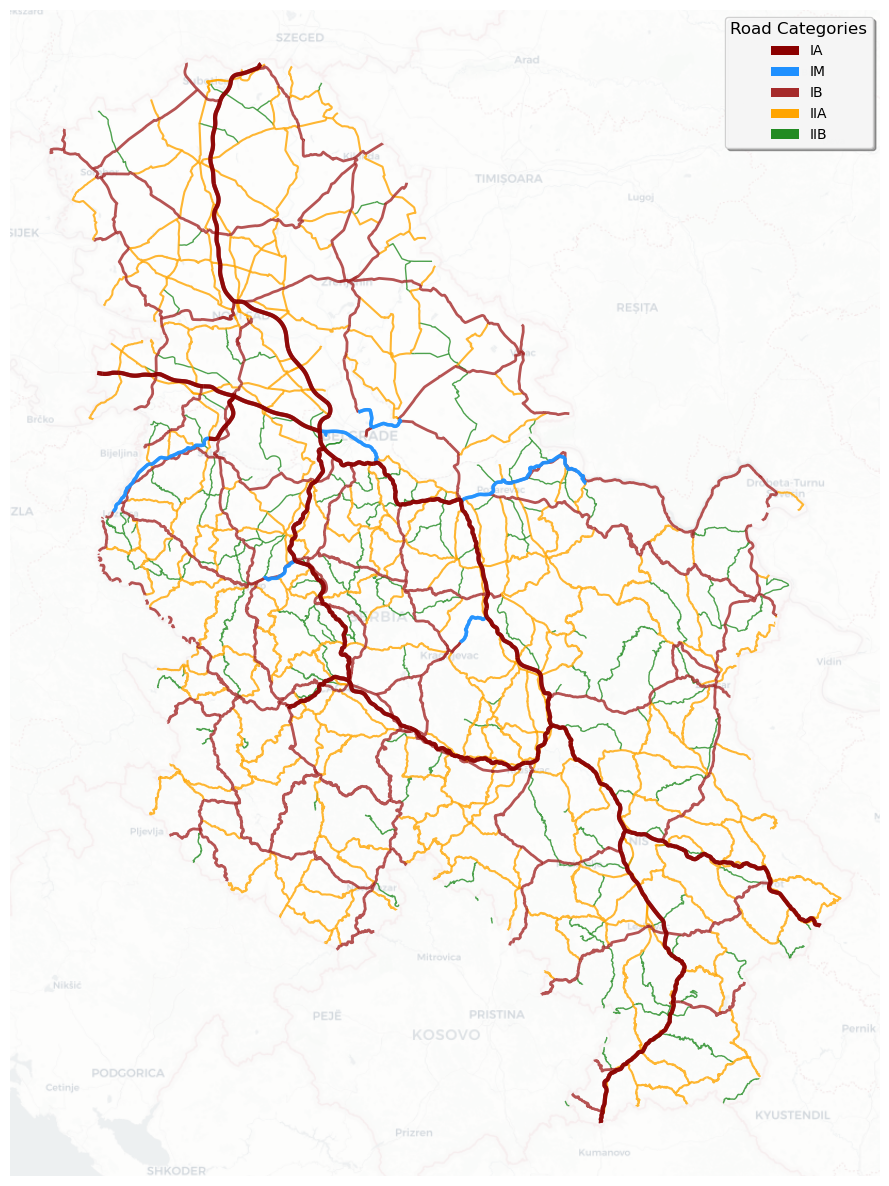

In [6]:
road_categories = ['IA', 'IM', 'IB', 'IIA', 'IIB']
gdf_filtered = roads[roads['kategorija'].isin(road_categories)].copy()

road_colors = {
    'IA': '#8B0000',   # Dark red/maroon
    'IM': '#1E90FF',   # Blue
    'IB': '#A52A2A',   # Dark red/brown
    'IIA': '#FFA500',  # Orange
    'IIB': '#228B22',  # Green
}

road_widths = {
    'IA': 3.0,
    'IM': 2.5,
    'IB': 2.0,
    'IIA': 1.5,
    'IIB': 1.0,
}

fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor='white')

gdf_mercator = gdf_filtered.to_crs(3857)

for category in road_categories:
    if category in gdf_filtered['kategorija'].values:
        category_roads = gdf_mercator[gdf_mercator['kategorija'] == category]
        category_roads.plot(
            ax=ax, color=road_colors[category],
            linewidth=road_widths[category], alpha=0.8,
            zorder=road_widths[category],
        )

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron,
               alpha=0.4, attribution=False)
ax.set_aspect('equal')
ax.axis('off')

legend_elements = [
    Patch(facecolor=road_colors[cat], label=cat, edgecolor='none')
    for cat in road_categories
    if cat in gdf_filtered['kategorija'].values
]
ax.legend(handles=legend_elements, title='Road Categories',
          loc='upper right', fontsize=10, title_fontsize=12,
          frameon=True, fancybox=True, shadow=True,
          framealpha=0.9, facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'road_categories.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5: Save as ArcGIS Layers

In [7]:
save_lyrx_layer(
    gdf=roads,
    gpkg_path=arcgis_gpkg / "road_network.gpkg",
    lyrx_path=arcgis_results / "road_network.lyrx",
    layer_name="road_network",
    labels=road_categories,
    colors=[road_colors[c] for c in road_categories],
    width_mapping=road_widths,
    field="kategorija",
    title="Serbian Road Network by Category",
)

print("\n✅ Done! Open 'road_network.lyrx' in ArcGIS Pro to view the styled road network.")

Saved GeoPackage → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\Geopackages\road_network.gpkg
Saved layer file → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\road_network.lyrx

✅ Done! Open 'road_network.lyrx' in ArcGIS Pro to view the styled road network.
